In [62]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [66]:
dataset = baseClasses.Data()

# First Normal Operation Period

Goal is to evaluate the temperature difference measured at the inlets

In [ ]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 15)) & (dataset.data.index < datetime.datetime(2024, 8, 1)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [68]:
pipes = systemClasses.System(dataset, "PIPE")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  6.19sensor/s]

ERROR: Channel (TE0120) not found


In [73]:
pressure = sensorClasses.Sensor(dataset, id=1037)

In [41]:
mux1 = muxClasses.MUX(dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset, boardNumber=4)

In [26]:
bulk = observableClasses.Bulk(dataset)
bulk.define()

Configuration-aware bulk temperature setup:

Configuration: baseline
Time period: 2024-06-15 00:01:00 to 2024-07-31 23:59:00

  System: TGRAD
  Boards 1-4: 1.0, 2.0
  Channels: TE0001, TE0002, TE0003, TE0004, TE0005, TE0006, TE0007, TE0008, TE0009, TE0010 ... (+38 more)

  System: HAWAI
  Boards 1-4: 3.0
  Channels: TE0049, TE0050, TE0051, TE0052, TE0053, TE0054, TE0055, TE0056, TE0057, TE0058 ... (+14 more)

  System: PP
  Boards 1-4: 4.0
  Channels: TE0073, TE0074

  System: PRM
  Boards 1-4: 4.0
  Channels: TE0079, TE0080, TE0081, TE0082, TE0083, TE0084

  System: PIPE
  Boards 1-4: 4.0
  Channels: TE0085, TE0086, TE0087, TE0088, TE0089, TE0090, TE0091, TE0092, TE0093, TE0094 ... (+2 more)


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 11.32sensor/s]


ERROR: Channel (TE0120) not found

Processing configurations for bulk temperature calculation...

Processing configuration: baseline


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 11.14sensor/s]
Calibrating TGRAD Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 48/48 [00:00<00:00, 101.22sensor/s]


      Debug sensor 39666: name='TGRAD1', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39665: name='TGRAD2', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39664: name='TGRAD3', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39667: name='TGRAD4', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39661: name='TGRAD5', system='TGRAD', board=1.0, calibrated=True
    TGRAD: 48 total sensors
      High precision (boards 1-4, calibrated): 48
      Far from inlets (>1500mm): 36
      Far from CE (>1500mm): 36
      Below interface (Y<6100mm): 25
      Final qualifying sensors: 25


...

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 10.21sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 12/12 [00:00<00:00, 82.67sensor/s]


    PIPE: 12 total sensors
      High precision (boards 1-4, calibrated): 12
      Far from inlets (>1500mm): 4
      Far from CE (>1500mm): 4
      Below interface (Y<6100mm): 4
      Final qualifying sensors: 4
Configuration baseline: 45 sensors included from systems ['TGRAD', 'HAWAI', 'PP', 'PRM', 'PIPE']


In [28]:
print(bulk.bulk["baseline"])

{'data':                           temp       err
Unnamed: 0                              
2024-06-15 00:01:00        NaN       NaN
2024-06-15 00:02:00        NaN       NaN
2024-06-15 00:03:00  87.648826  0.010283
2024-06-15 00:04:00        NaN       NaN
2024-06-15 00:05:00        NaN       NaN
...                        ...       ...
2024-07-31 23:55:00  87.653024  0.011171
2024-07-31 23:56:00  87.652834  0.010890
2024-07-31 23:57:00  87.652619  0.010363
2024-07-31 23:58:00  87.652564  0.010780
2024-07-31 23:59:00  87.652644  0.010493

[67679 rows x 2 columns], 'weights': {39651: 0.02291156133732949, 39650: 0.023064703005480598, 40526: 0.0231961706593817, 40525: 0.023307633173692045, 40524: 0.02340083813633524, 39659: 0.023477582395293906, 39658: 0.023539682700463416, 39657: 0.023627145707152068, 39649: 0.023677087375540754, 39648: 0.023701959609427795, 39647: 0.02371209185348175, 39646: 0.023715117578632778, 39644: 0.023715560776240735, 39630: 0.023714594865807636, 39629: 0.023709980

In [69]:
pipes.calibrate("FIRST_POFF_PIPES")

Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  6.10sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 12/12 [00:00<00:00, 51.91sensor/s]


In [7]:
print(pipes.sensors)

{49319: <src.sensorClasses.Sensor object at 0x1320c88b0>, 39671: <src.sensorClasses.Sensor object at 0x1320fb640>, 39631: <src.sensorClasses.Sensor object at 0x13397b760>, 49320: <src.sensorClasses.Sensor object at 0x131c44a30>, 37131: <src.sensorClasses.Sensor object at 0x131be6470>, 39670: <src.sensorClasses.Sensor object at 0x130effbe0>, 49321: <src.sensorClasses.Sensor object at 0x130ee93c0>, 37136: <src.sensorClasses.Sensor object at 0x130f6abf0>, 37130: <src.sensorClasses.Sensor object at 0x131dc38b0>, 49322: <src.sensorClasses.Sensor object at 0x131e2fdf0>, 39669: <src.sensorClasses.Sensor object at 0x130b0d300>, 37133: <src.sensorClasses.Sensor object at 0x130ae20b0>}


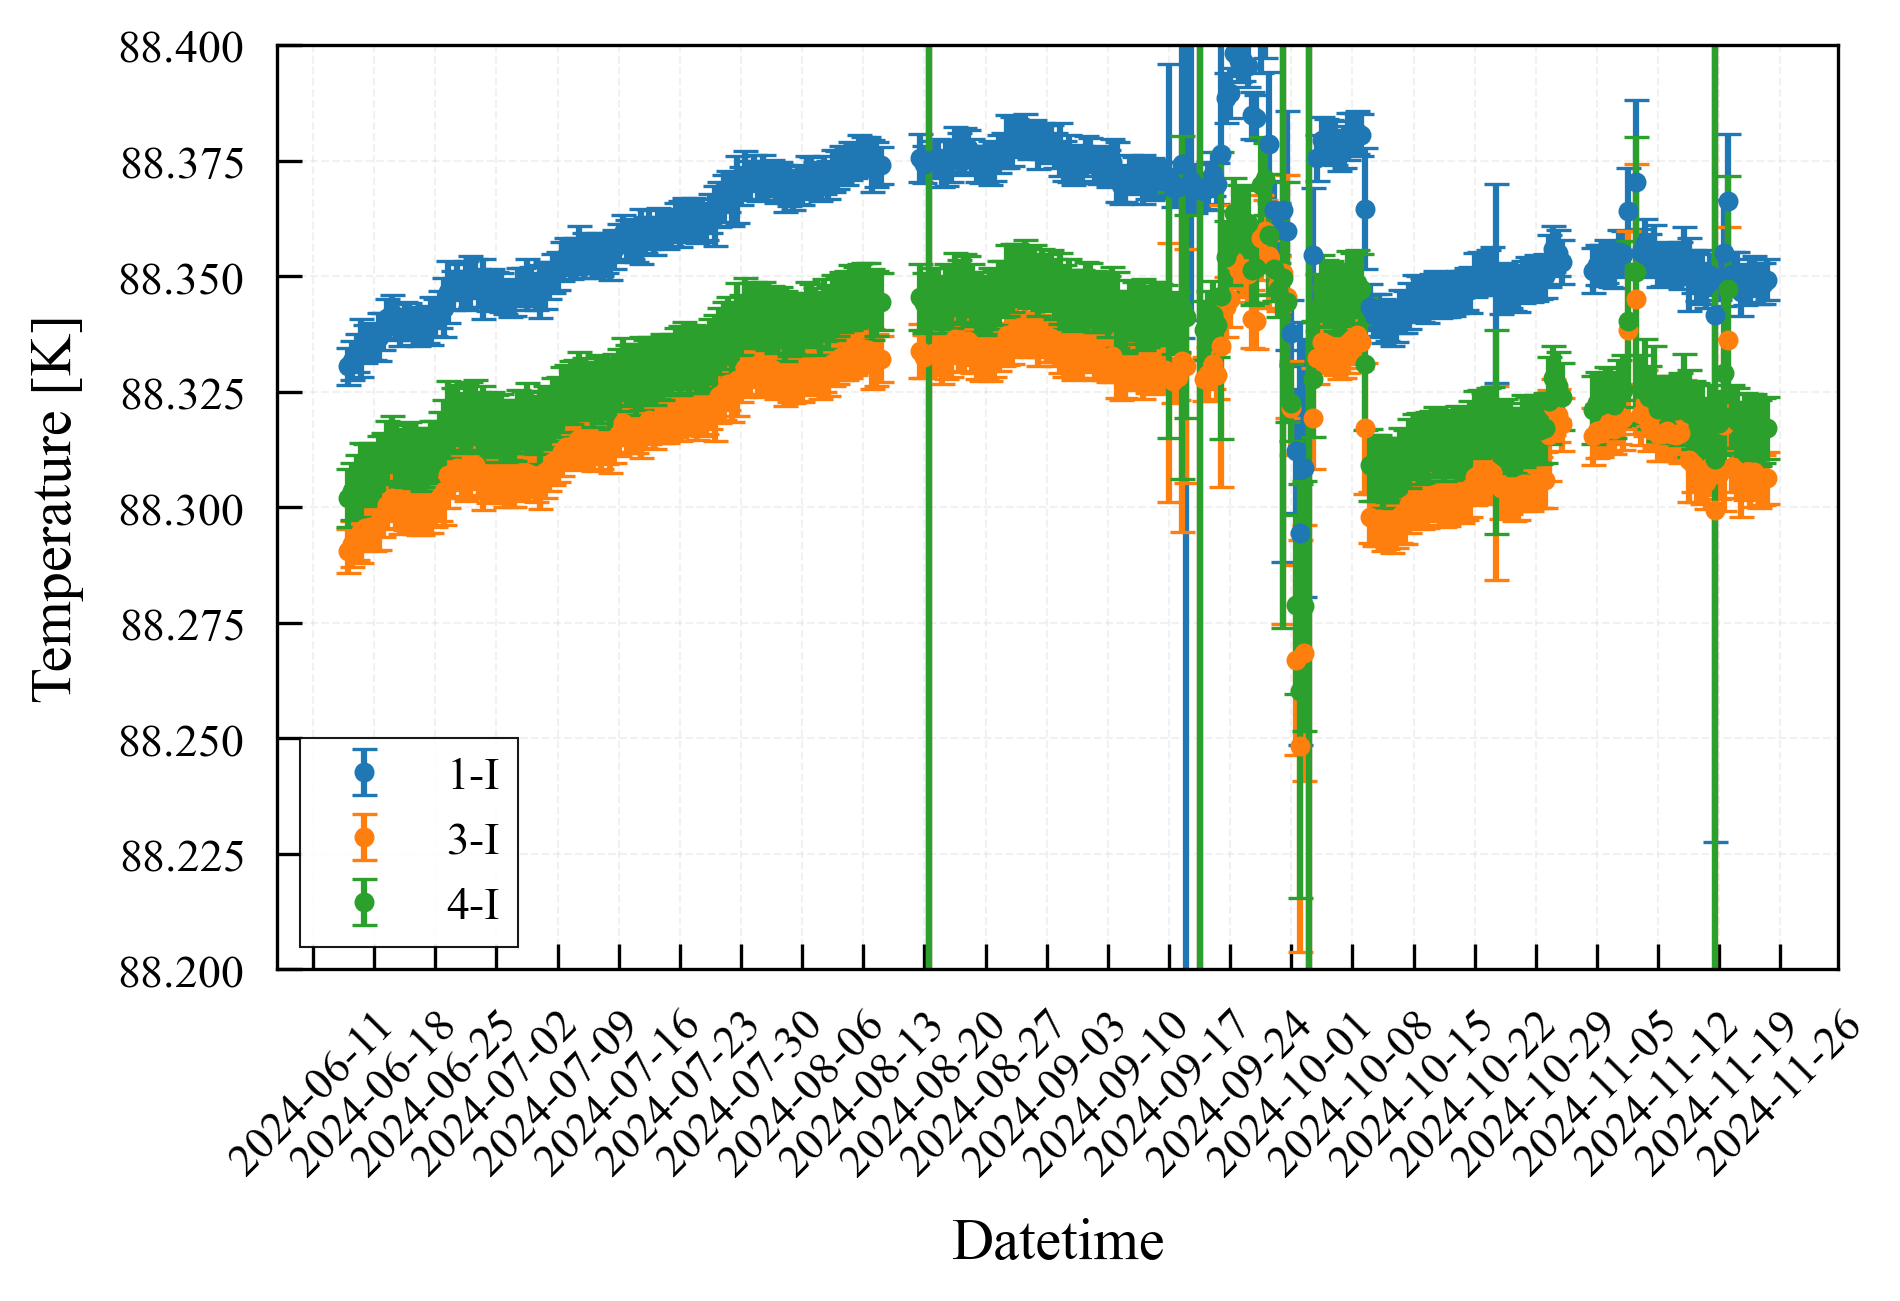

In [72]:
resampling_time = "12H"
fig, axes = plt.subplots(1,1)

axes.errorbar(pipes.sensors[49319].data.resample(resampling_time).mean().index.values, pipes.sensors[49319].data.resample(resampling_time).mean().values, yerr=pipes.sensors[49319].data.resample(resampling_time).std().values, fmt="o", label=pipes.sensors[49319].name)
axes.errorbar(pipes.sensors[49321].data.resample(resampling_time).mean().index.values, pipes.sensors[49321].data.resample(resampling_time).mean().values, yerr=pipes.sensors[49321].data.resample(resampling_time).std().values, fmt="o", label=pipes.sensors[49321].name)
axes.errorbar(pipes.sensors[49322].data.resample(resampling_time).mean().index.values, pipes.sensors[49322].data.resample(resampling_time).mean().values, yerr=pipes.sensors[49322].data.resample(resampling_time).std().values, fmt="o", label=pipes.sensors[49322].name)

axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.set_ylim(88.2, 88.4)
# Format x-axis for datetime
axes.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes.xaxis.set_major_locator(mdates.DayLocator(interval=7))  # Show every 7 days

axes.tick_params(axis='x', rotation=45)  # Rotate labels for better readability
axes.legend()
plt.tight_layout()  # Adjust layout to prevent label cutoff

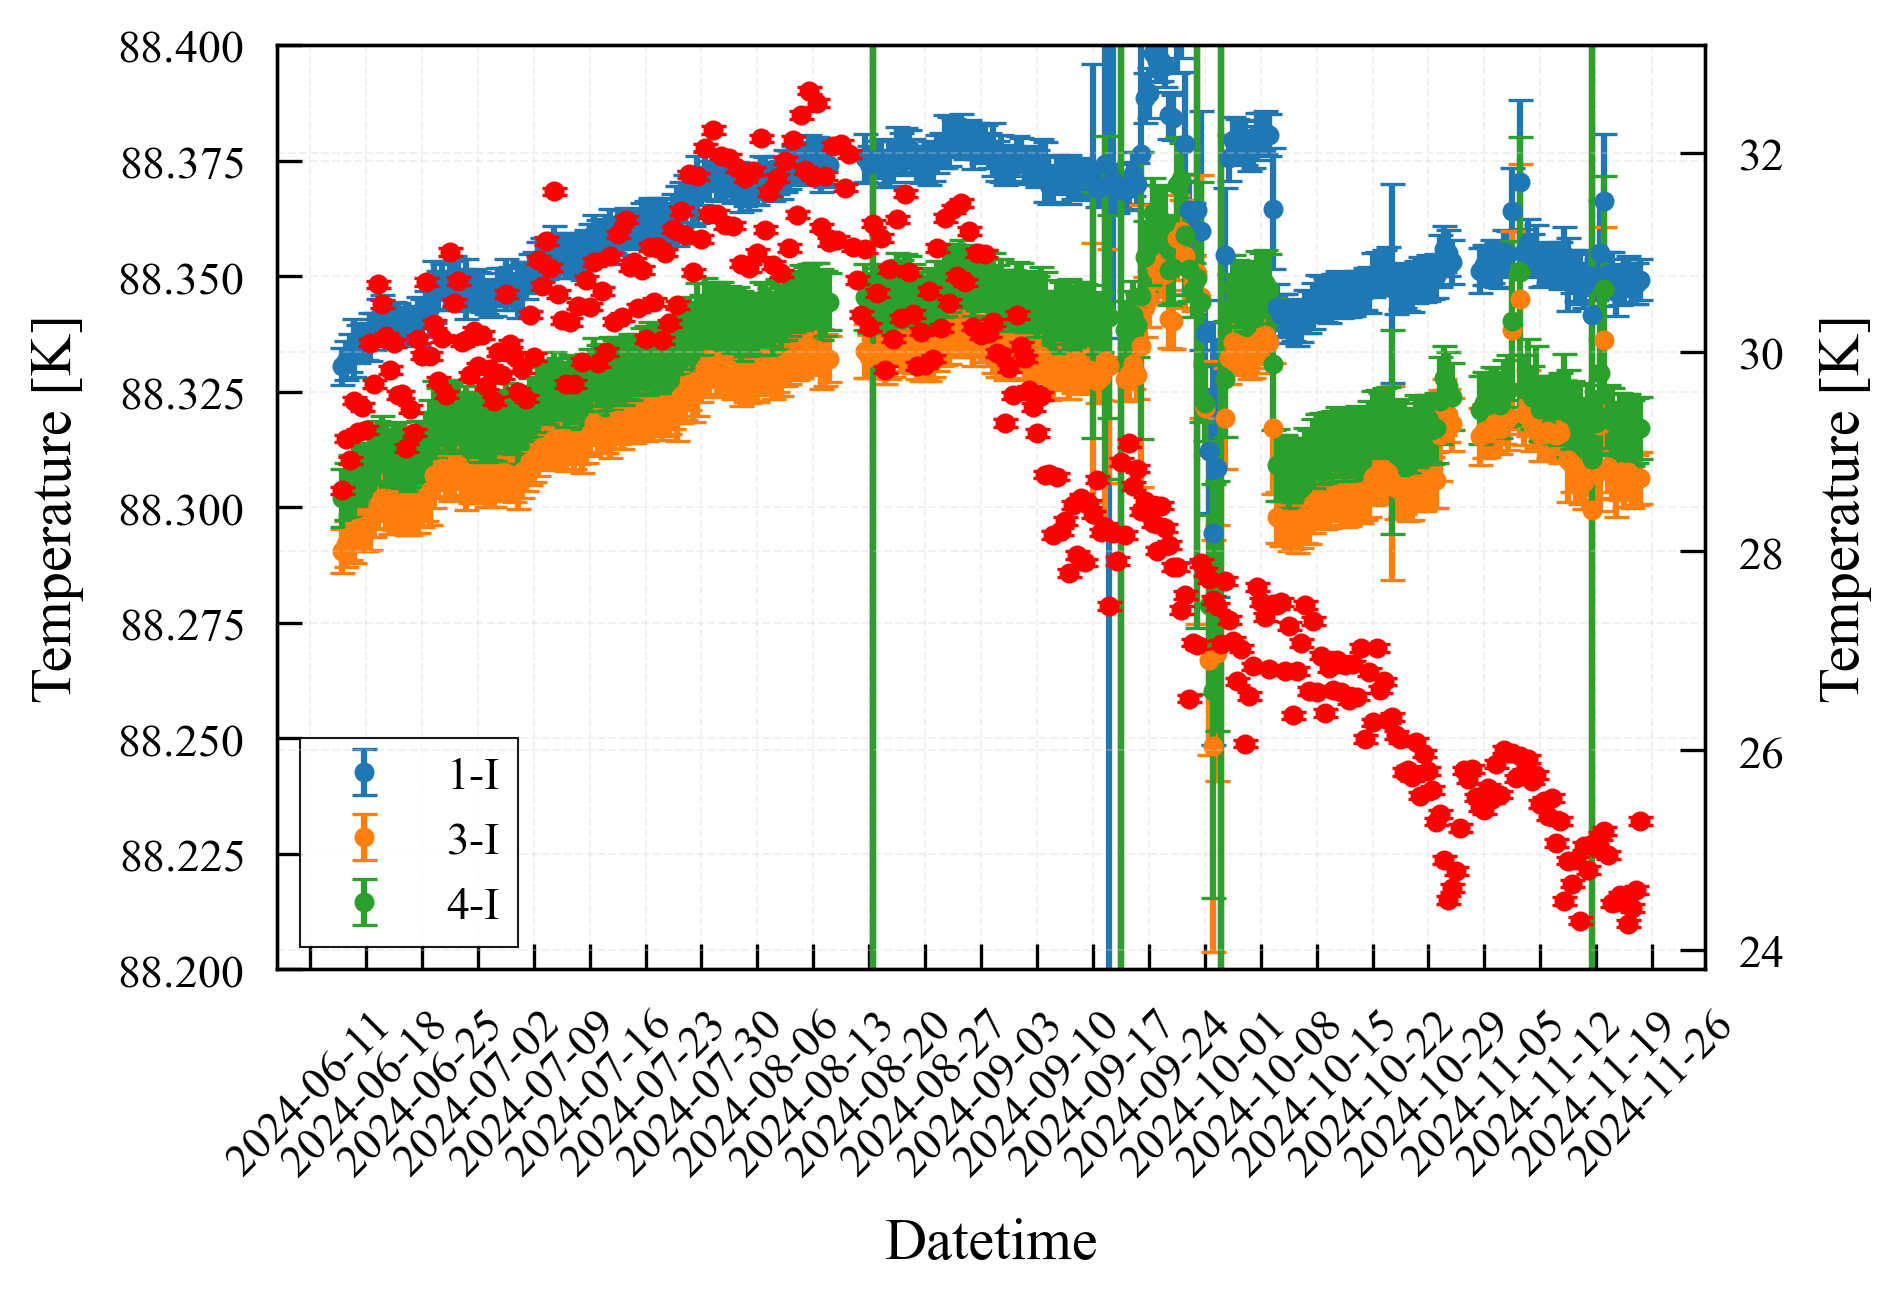

In [75]:
resampling_time = "12H"
fig, axes = plt.subplots(1,1)
axes2 = axes.twinx()
axes.errorbar(pipes.sensors[49319].data.resample(resampling_time).mean().index.values, pipes.sensors[49319].data.resample(resampling_time).mean().values, yerr=pipes.sensors[49319].data.resample(resampling_time).std().values, fmt="o", label=pipes.sensors[49319].name)
axes.errorbar(pipes.sensors[49321].data.resample(resampling_time).mean().index.values, pipes.sensors[49321].data.resample(resampling_time).mean().values, yerr=pipes.sensors[49321].data.resample(resampling_time).std().values, fmt="o", label=pipes.sensors[49321].name)
axes.errorbar(pipes.sensors[49322].data.resample(resampling_time).mean().index.values, pipes.sensors[49322].data.resample(resampling_time).mean().values, yerr=pipes.sensors[49322].data.resample(resampling_time).std().values, fmt="o", label=pipes.sensors[49322].name)

axes.set_ylim(88.2, 88.4)
# axes2.errorbar(bulk.bulk["baseline"]["data"].resample(resampling_time).mean().index.values, bulk.bulk["baseline"]["data"]["temp"].resample(resampling_time).mean().values, yerr=bulk.bulk["baseline"]["data"]["temp"].resample(resampling_time).std().values, color="purple", fmt="o", label="Bulk")
axes2.errorbar(pressure.data.resample(resampling_time).mean().index.values, pressure.data.resample(resampling_time).mean().values, yerr=pressure.err.resample(resampling_time).mean().values, color="red", fmt="o", label="Pressure")



axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes2.set_ylabel("Temperature [K]")


# Format x-axis for datetime
axes.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes.xaxis.set_major_locator(mdates.DayLocator(interval=7))  # Show every 7 days

axes.tick_params(axis='x', rotation=45)  # Rotate labels for better readability
axes.legend()
plt.tight_layout()  # Adjust layout to prevent label cutoff